# Germany Baseline: OLG Model Simulation

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.demographics import bgp_growth_rate, simulate_cohort_sizes
from src.bgp import bgp_interest_rate
from src.olg import solve_transition

In [2]:
# Locked-in calibrated parameters
params = dict(
    alpha = 0.33,   # capital share
    sigma = 0.4,    # low substitutability (production literature)
    delta = 0.05,   # annual depreciation
    beta  = 0.946,  # calibrated to match pre-shock r = 3.5%
    theta = 2.0,    # inverse EIS
    gamma = 0.015,  # Germany per-capita GDP growth
    J     = 80,
    chi   = 20,
    psi   = 60,
)
F_low, F_high = 20, 30
b_high = 2.5 / 20   # two-sex birth rate (TFR=2.5)
b_low  = 1.4 / 20   # two-sex birth rate (TFR=1.4)
shock_year = 1970

print(f"{'Parameter':<10} {'Value'}")
print("-" * 22)
for k, v in params.items():
    print(f"  {k:<8} {v}")
print(f"  {'b_high':<8} {b_high}  (TFR=2.5, two-sex)")
print(f"  {'b_low':<8} {b_low}  (TFR=1.4, two-sex)")

Parameter  Value
----------------------
  alpha    0.33
  sigma    0.4
  delta    0.05
  beta     0.946
  theta    2.0
  gamma    0.015
  J        80
  chi      20
  psi      60
  b_high   0.125  (TFR=2.5, two-sex)
  b_low    0.06999999999999999  (TFR=1.4, two-sex)


In [3]:
g_high = bgp_growth_rate(b_high, J=params['J'], F_low=F_low, F_high=F_high)
g_low  = bgp_growth_rate(b_low,  J=params['J'], F_low=F_low, F_high=F_high)

r_init     = bgp_interest_rate(g_high, b_high, **params)
r_terminal = bgp_interest_rate(g_low,  b_low,  **params)

print(f"g_high     = {g_high*100:.4f}%")
print(f"g_low      = {g_low*100:.4f}%")
print(f"r_init     = {r_init*100:.4f}%")
print(f"r_terminal = {r_terminal*100:.4f}%")

g_high     = 0.9164%
g_low      = -1.4418%
r_init     = 3.5121%
r_terminal = 1.5260%


In [4]:
dem = simulate_cohort_sizes(b_high, b_low, shock_year=shock_year,
                             base_year=1900, end_year=2200,
                             J=params['J'], F_low=F_low, F_high=F_high)

result = solve_transition(
    dem['cohort_sizes'], dem['years'],
    r_init=r_init, r_terminal=r_terminal,
    phi=0.05, max_iter=2000, tol=1e-6,
    **params
)

r_path = result['r_path']
yrs    = result['years']
trough_idx = np.argmin(r_path)
trough_r   = r_path[trough_idx]
trough_yr  = int(yrs[trough_idx])
overshoot  = r_terminal - trough_r

print(f"r_init     = {r_init*100:.3f}%")
print(f"r_terminal = {r_terminal*100:.3f}%")
print(f"trough     = {trough_r*100:.3f}%  (year {trough_yr})")
print(f"overshoot  = {overshoot*10000:.1f} bp below terminal")
print(f"converged  = {result['converged']}  ({result['n_iter']} iterations)")

r_init     = 3.512%
r_terminal = 1.526%
trough     = 0.685%  (year 2028)
overshoot  = 84.1 bp below terminal
converged  = True  (148 iterations)


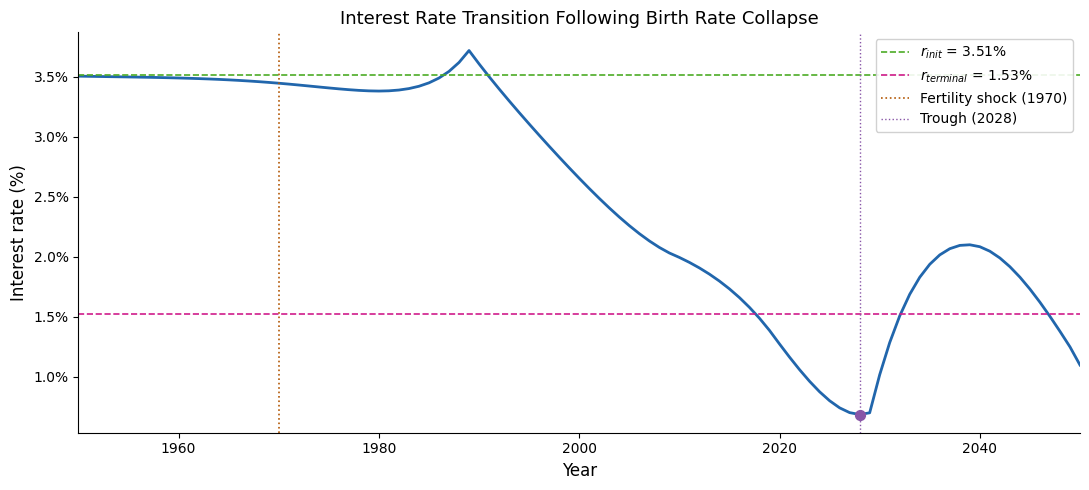

Saved figures/germany_baseline.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
mask_plot = (yrs >= 1950) & (yrs <= 2050)
ax.plot(yrs[mask_plot], r_path[mask_plot] * 100, color='#2166ac', lw=2)
ax.axhline(r_init * 100,     color='#4dac26', lw=1.2, ls='--',
           label=f'$r_{{init}}$ = {r_init*100:.2f}%')
ax.axhline(r_terminal * 100, color='#d01c8b', lw=1.2, ls='--',
           label=f'$r_{{terminal}}$ = {r_terminal*100:.2f}%')
ax.axvline(shock_year, color='#b35806', lw=1.2, ls=':', label='Fertility shock (1970)')
ax.axvline(trough_yr,  color='#8856a7', lw=1.0, ls=':', label=f'Trough ({trough_yr})')
ax.scatter([trough_yr], [trough_r * 100], color='#8856a7', zorder=5, s=50)
ax.set_xlim(1950, 2050)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Interest rate (%)', fontsize=12)
ax.set_title('Interest Rate Transition Following Birth Rate Collapse', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(loc='upper right', framealpha=0.9, fontsize=10)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
fig.savefig('../figures/germany_baseline.png', dpi=150)
plt.show()
print("Saved figures/germany_baseline.png")

## Interpretation

The model generates a roughly 3 percentage point decline in real interest rates from the pre-shock BGP (3.5%) to the trough in 2028 (0.68%). The mechanism is a savings glut: the large baby-boom cohorts born before 1970 enter their peak saving years (ages 40–60) from the 1990s onward, pushing asset demand above capital supply and driving the equilibrium rate down. The trough in 2028 coincides with peak asset holdings of the baby-boom generation; as they retire and dissave, the rate rebounds, overshooting the new BGP of 1.53% before converging. The 84 bp overshoot below terminal reflects the low substitutability of capital (σ=0.4): firms cannot easily absorb the savings glut, amplifying the rate decline during the transition.